# Hierarchical Clustering

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

## Imports

In [21]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Scipy imports for Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster, cophenet
from scipy.spatial.distance import pdist

# Sklearn imports
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

In [22]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")

## Features Selection

In [23]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    'loudness',
    'spectral_complexity',
    # 'flux',
    'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    # 'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [24]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [25]:
# Check for NaN values
print(X.isna().sum())

centroid               0
loudness               0
spectral_complexity    0
rolloff                0
popularity             0
aggressiveness         0
dtype: int64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [26]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [27]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

In [28]:
X_scaled = X_minmax

### Study of Clustering Parameters

In [ ]:
def analyze_hierarchical_method(X_scaled, X_original, method, k_range=range(2, 7)):
    """
    Complete pipeline for Hierarchical Clustering Analysis:
    1. Plots Dendrogram
    2. Grid Search for K (Silhouette & Distribution)
    3. Visualizes Best K (PCA)
    4. Characterizes Best K (Feature Means)
    """
    
    # --- 1. Dendrogram ---
    plt.figure(figsize=(12, 5))
    plt.title(f"Dendrogram ({method} linkage)")
    Z = linkage(X_scaled, method=method, metric='euclidean')
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., show_contracted=False)
    plt.xlabel("Cluster Size / ID")
    plt.ylabel("Distance")
    plt.show()

    # --- 2. Tuning K (Silhouette & Distribution) ---
    best_k = 0
    best_score = -1
    best_labels = None
    results = []

    for k in k_range:
        hc = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = hc.fit_predict(X_scaled)
        
        score = silhouette_score(X_scaled, labels)
        counts = pd.Series(labels).value_counts().sort_index()
        
        results.append({
            'k': k,
            'silhouette': score,
            'counts': counts,
            'labels': labels
        })
        
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels

        # --- PRINT DISTRIBUTION + SILHOUETTE ---
        print(f"\nClustering k = {k}:")
        print(f"  Silhouette score = {score:.4f}")
        for cluster_id, count in counts.items():
            print(f"  Cluster {cluster_id}: {count} samples")

    # --- Silhouette Score Plot (ALONE) ---
    results_df = pd.DataFrame({
        'k': [r['k'] for r in results],
        'silhouette': [r['silhouette'] for r in results]
    })

    plt.figure(figsize=(8, 5))
    sns.lineplot(
        data=results_df,
        x='k',
        y='silhouette',
        marker='o',
        color='purple'
    )
    plt.title(f'Silhouette Score vs K ({method})')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

    # --- Cluster Distribution Plot (ALONE) ---
    dist_data = []
    for res in results:
        for c_id, count in res['counts'].items():
            dist_data.append({
                'k': res['k'],
                'cluster': c_id,
                'count': count
            })
    dist_df = pd.DataFrame(dist_data)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=dist_df,
        x='k',
        y='count',
        hue='cluster',
        palette='viridis'
    )
    plt.title(f'Cluster Size Distribution by K ({method})')
    plt.tight_layout()
    plt.show()

    # --- Best K Summary ---
    best_res = next(r for r in results if r['k'] == best_k)
    print(f"\n--> BEST CONFIGURATION")
    print(f"Clustering k = {best_k}:")
    print(f"  Silhouette score = {best_score:.4f}")
    for cluster_id, count in best_res['counts'].items():
        print(f"  Cluster {cluster_id}: {count} samples")

    # --- 3. PCA Visualization ---
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=best_labels,
        cmap='viridis',
        s=20,
        alpha=0.6
    )
    plt.title(f"{method.capitalize()} Linkage (k={best_k}) - PCA Projection")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label='Cluster Label')
    plt.show()

    # --- 4. Cluster Characterization ---
    df_analysis = X_original.copy()
    df_analysis['cluster'] = best_labels
    
    cluster_means = df_analysis.groupby('cluster').mean()
    global_means = X_original.mean()
    
    print("\n--- CLUSTER PROFILES (Original Scale) ---")
    print(cluster_means)
    
    print("\n--- DEVIATION FROM GLOBAL MEAN ---")
    print(cluster_means - global_means)
    
    return results_df

### Ward Linkage


==================== ANALYZING: WARD LINKAGE ====================


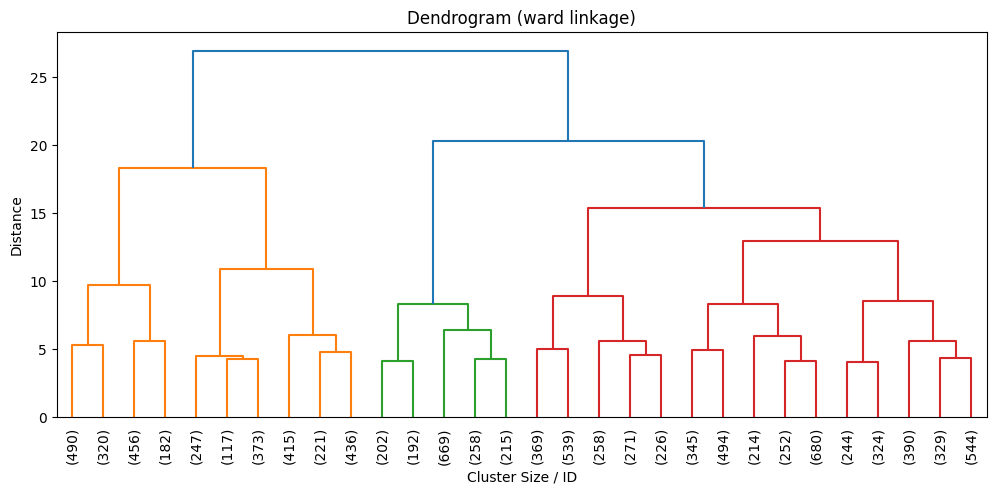


Clustering k = 2:
  Silhouette score = 0.1856
  Cluster 0: 7015 samples
  Cluster 1: 3257 samples

Clustering k = 3:
  Silhouette score = 0.1279
  Cluster 0: 3257 samples
  Cluster 1: 5479 samples
  Cluster 2: 1536 samples

Clustering k = 4:
  Silhouette score = 0.1290
  Cluster 0: 5479 samples
  Cluster 1: 1809 samples
  Cluster 2: 1536 samples
  Cluster 3: 1448 samples

Clustering k = 5:
  Silhouette score = 0.1197
  Cluster 0: 3816 samples
  Cluster 1: 1809 samples
  Cluster 2: 1536 samples
  Cluster 3: 1448 samples
  Cluster 4: 1663 samples

Clustering k = 6:
  Silhouette score = 0.0981
  Cluster 0: 1809 samples
  Cluster 1: 1448 samples
  Cluster 2: 1536 samples
  Cluster 3: 1831 samples
  Cluster 4: 1663 samples
  Cluster 5: 1985 samples


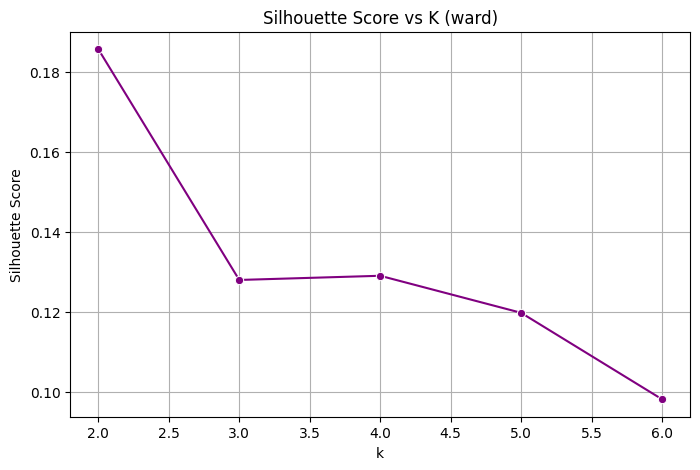

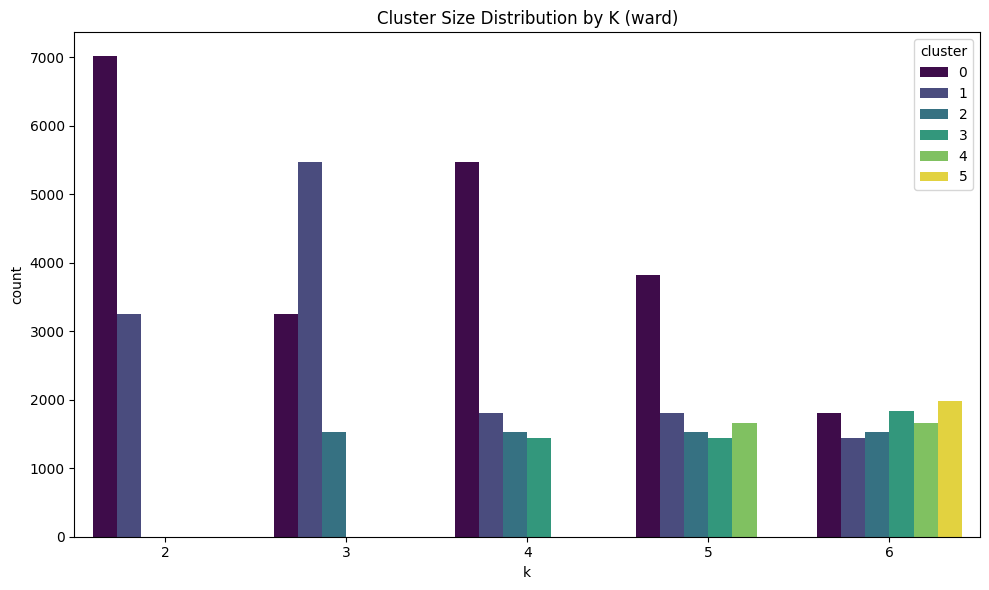


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.1856
  Cluster 0: 7015 samples
  Cluster 1: 3257 samples


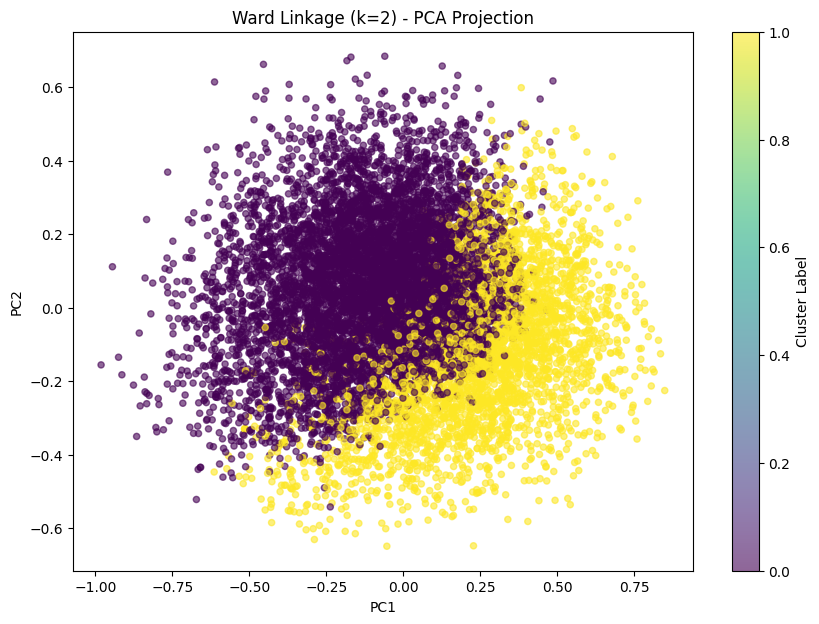


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.128281  25.483471             26.89962  6.062905   36.353243   
1        0.161896  23.138953             30.41826  6.760849   25.646300   

         aggressiveness  
cluster                  
0             -0.116946  
1              0.370368  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid  loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                  
0       -0.010659  0.743389            -1.115675 -0.221301    3.394910   
1        0.022957 -1.601129             2.402965  0.476643   -7.312033   

         aggressiveness  
cluster                  
0             -0.154515  
1              0.332798  


In [ ]:
ward_results = analyze_hierarchical_method(X_scaled, X, method='ward')

### Single Linkage


==================== ANALYZING: SINGLE LINKAGE ====================


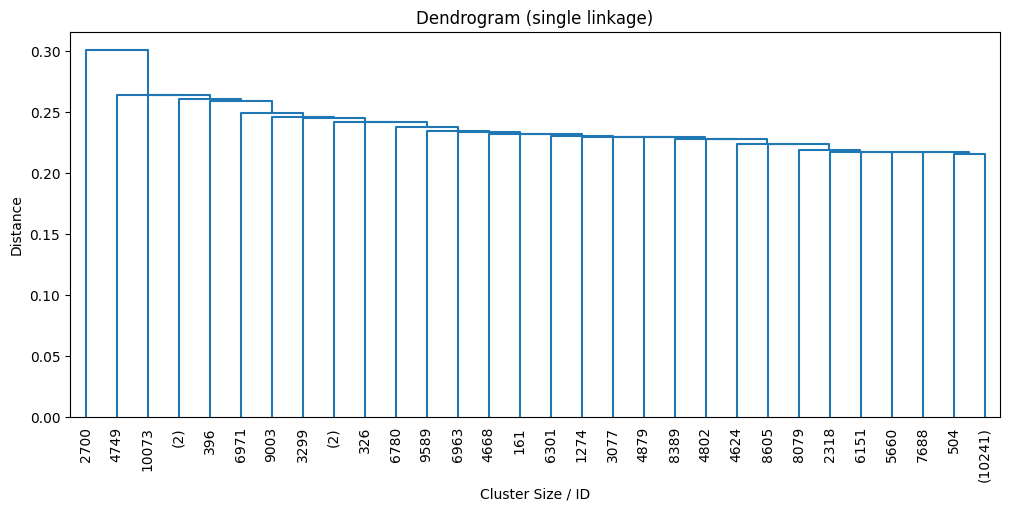


Clustering k = 2:
  Silhouette score = 0.3889
  Cluster 0: 10271 samples
  Cluster 1: 1 samples

Clustering k = 3:
  Silhouette score = 0.3024
  Cluster 0: 10270 samples
  Cluster 1: 1 samples
  Cluster 2: 1 samples

Clustering k = 4:
  Silhouette score = 0.2028
  Cluster 0: 10269 samples
  Cluster 1: 1 samples
  Cluster 2: 1 samples
  Cluster 3: 1 samples

Clustering k = 5:
  Silhouette score = 0.1996
  Cluster 0: 10267 samples
  Cluster 1: 2 samples
  Cluster 2: 1 samples
  Cluster 3: 1 samples
  Cluster 4: 1 samples

Clustering k = 6:
  Silhouette score = 0.1815
  Cluster 0: 10266 samples
  Cluster 1: 2 samples
  Cluster 2: 1 samples
  Cluster 3: 1 samples
  Cluster 4: 1 samples
  Cluster 5: 1 samples


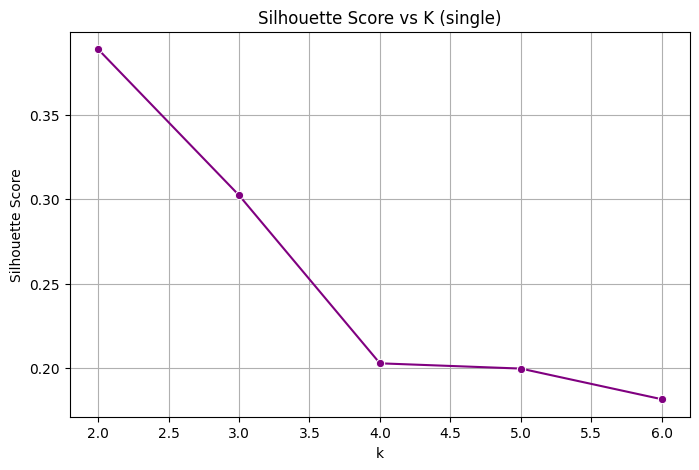

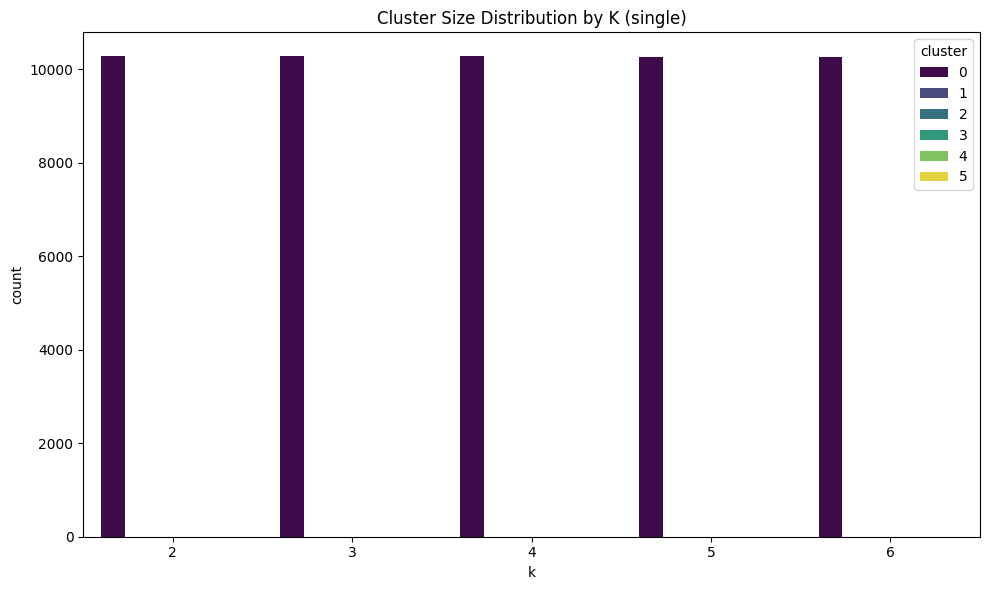


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.3889
  Cluster 0: 10271 samples
  Cluster 1: 1 samples


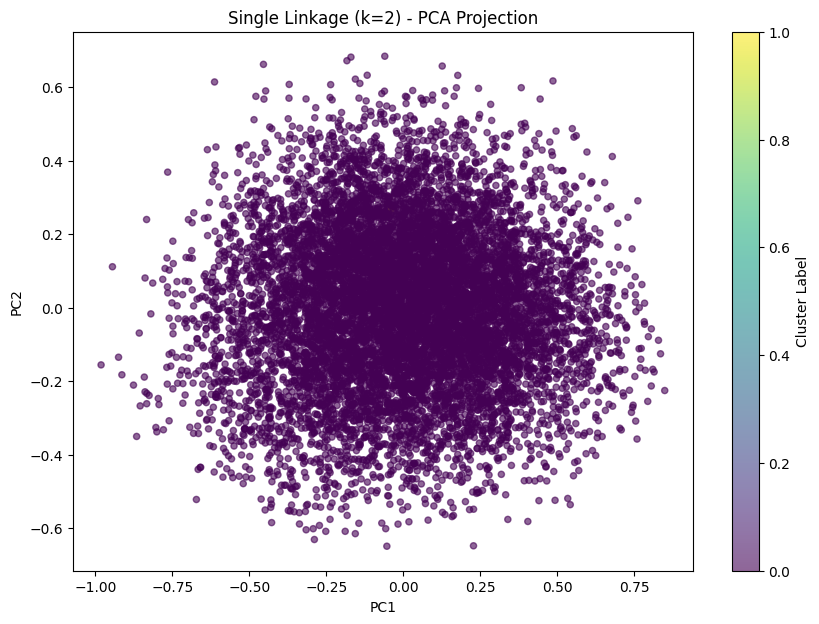


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.138945  24.737942            28.013229  6.284260   32.961055   
1        0.077600  46.717400            49.233200  5.725461    5.000000   

         aggressiveness  
cluster                  
0              0.037617  
1             -0.451525  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.000006  -0.002140            -0.002066  0.000054    0.002722   
1       -0.061339  21.977318            21.217905 -0.558745  -27.958333   

         aggressiveness  
cluster                  
0              0.000048  
1             -0.489095  


In [ ]:
single_results = analyze_hierarchical_method(X_scaled, X, method='single')

### Complete Linkage


==================== ANALYZING: COMPLETE LINKAGE ====================


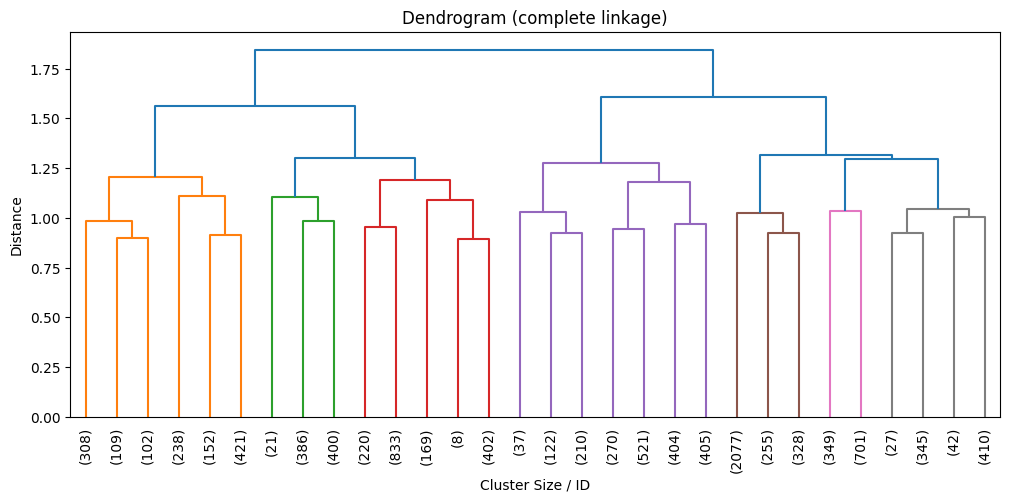


Clustering k = 2:
  Silhouette score = 0.1691
  Cluster 0: 6503 samples
  Cluster 1: 3769 samples

Clustering k = 3:
  Silhouette score = 0.0886
  Cluster 0: 3769 samples
  Cluster 1: 4534 samples
  Cluster 2: 1969 samples

Clustering k = 4:
  Silhouette score = 0.0691
  Cluster 0: 4534 samples
  Cluster 1: 2439 samples
  Cluster 2: 1969 samples
  Cluster 3: 1330 samples

Clustering k = 5:
  Silhouette score = 0.0605
  Cluster 0: 2439 samples
  Cluster 1: 1874 samples
  Cluster 2: 1969 samples
  Cluster 3: 1330 samples
  Cluster 4: 2660 samples

Clustering k = 6:
  Silhouette score = 0.0618
  Cluster 0: 1874 samples
  Cluster 1: 1330 samples
  Cluster 2: 1969 samples
  Cluster 3: 1632 samples
  Cluster 4: 2660 samples
  Cluster 5: 807 samples


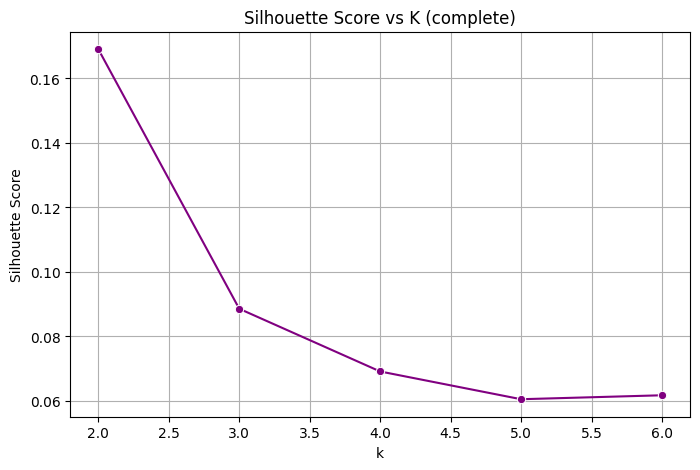

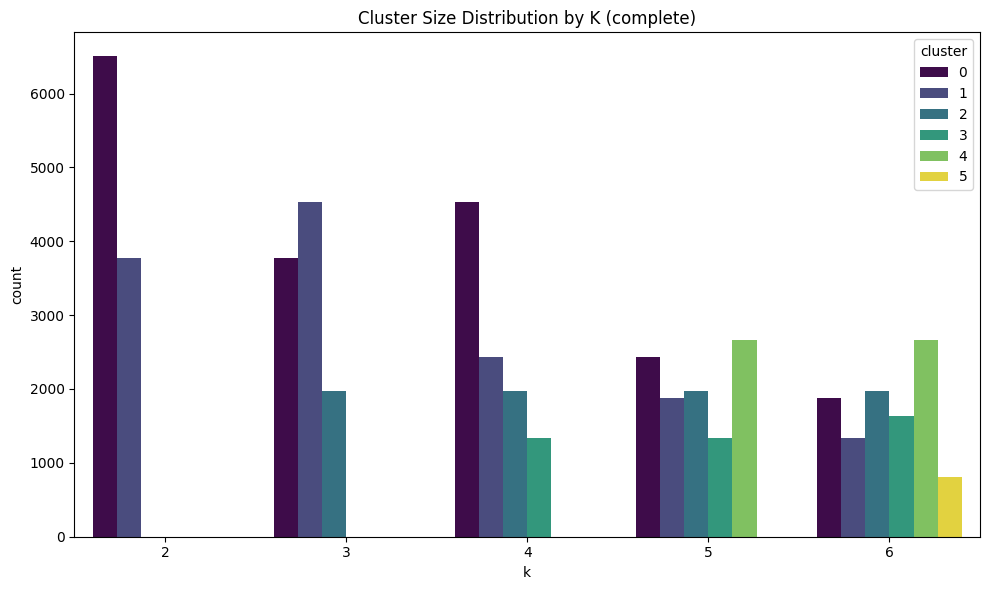


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.1691
  Cluster 0: 6503 samples
  Cluster 1: 3769 samples


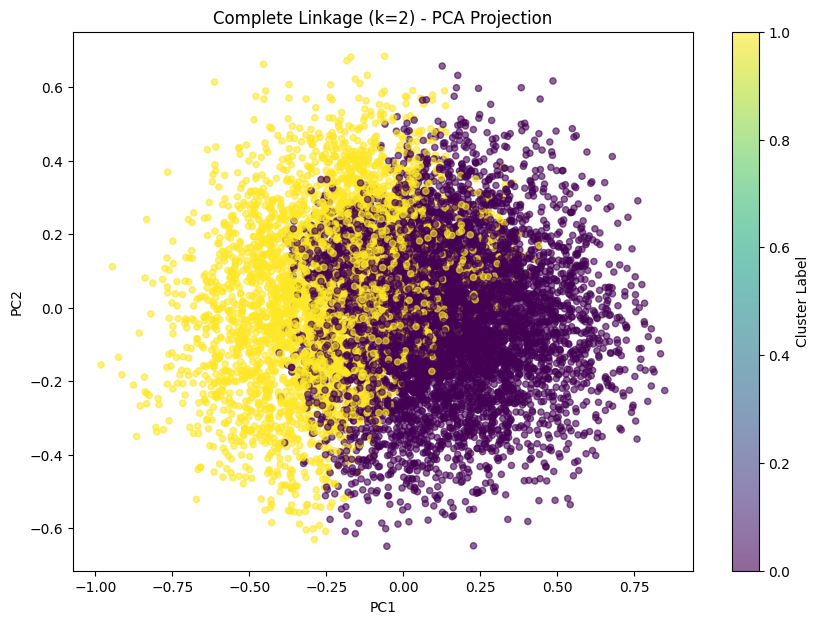


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.151042  24.846155            30.026566  6.535804   32.937875   
1        0.118057  24.557064            24.545064  5.850101   32.993632   

         aggressiveness  
cluster                  
0              0.228508  
1             -0.291875  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid  loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                  
0        0.012103  0.106073             2.011272  0.251598   -0.020459   
1       -0.020882 -0.183018            -3.470231 -0.434105    0.035299   

         aggressiveness  
cluster                  
0              0.190939  
1             -0.329444  


In [ ]:
complete_results = analyze_hierarchical_method(X_scaled, X, method='complete')

### Average Linkage


==================== ANALYZING: AVERAGE LINKAGE ====================


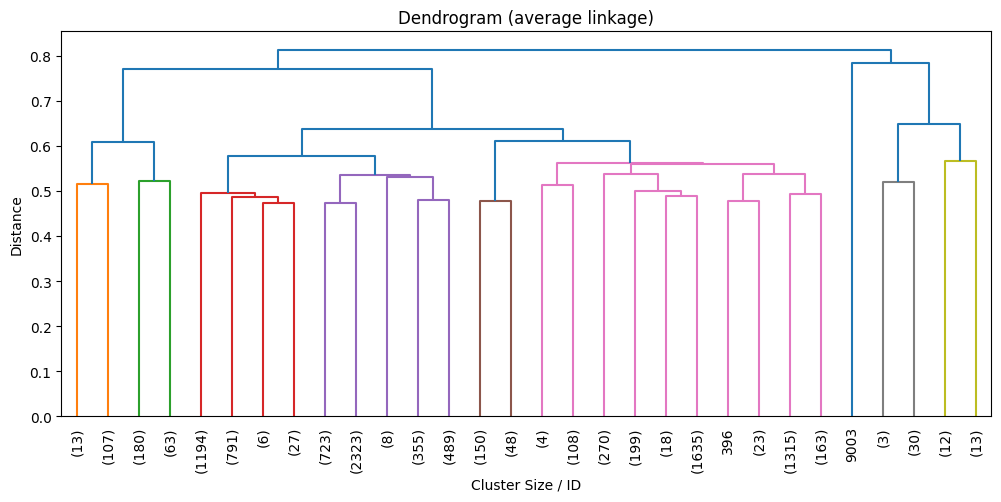


Clustering k = 2:
  Silhouette score = 0.2597
  Cluster 0: 59 samples
  Cluster 1: 10213 samples

Clustering k = 3:
  Silhouette score = 0.2124
  Cluster 0: 10213 samples
  Cluster 1: 58 samples
  Cluster 2: 1 samples

Clustering k = 4:
  Silhouette score = 0.1407
  Cluster 0: 58 samples
  Cluster 1: 9850 samples
  Cluster 2: 1 samples
  Cluster 3: 363 samples

Clustering k = 5:
  Silhouette score = 0.1137
  Cluster 0: 9850 samples
  Cluster 1: 363 samples
  Cluster 2: 1 samples
  Cluster 3: 25 samples
  Cluster 4: 33 samples

Clustering k = 6:
  Silhouette score = 0.0983
  Cluster 0: 3934 samples
  Cluster 1: 363 samples
  Cluster 2: 5916 samples
  Cluster 3: 25 samples
  Cluster 4: 33 samples
  Cluster 5: 1 samples


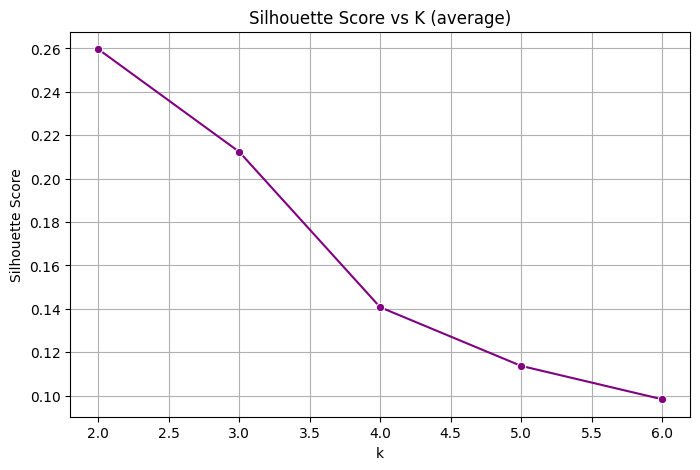

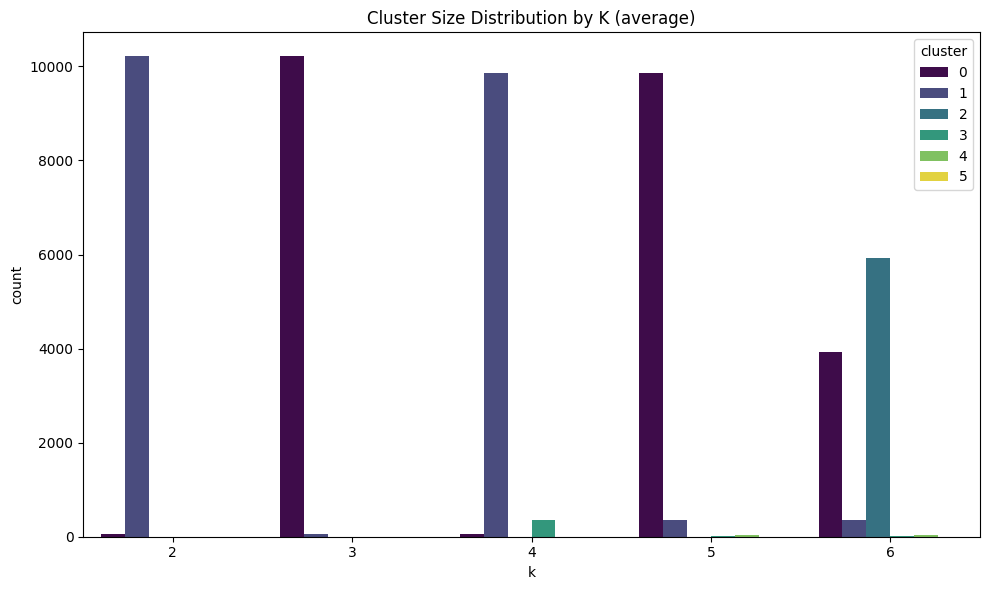


--> BEST CONFIGURATION
Clustering k = 2:
  Silhouette score = 0.2597
  Cluster 0: 59 samples
  Cluster 1: 10213 samples


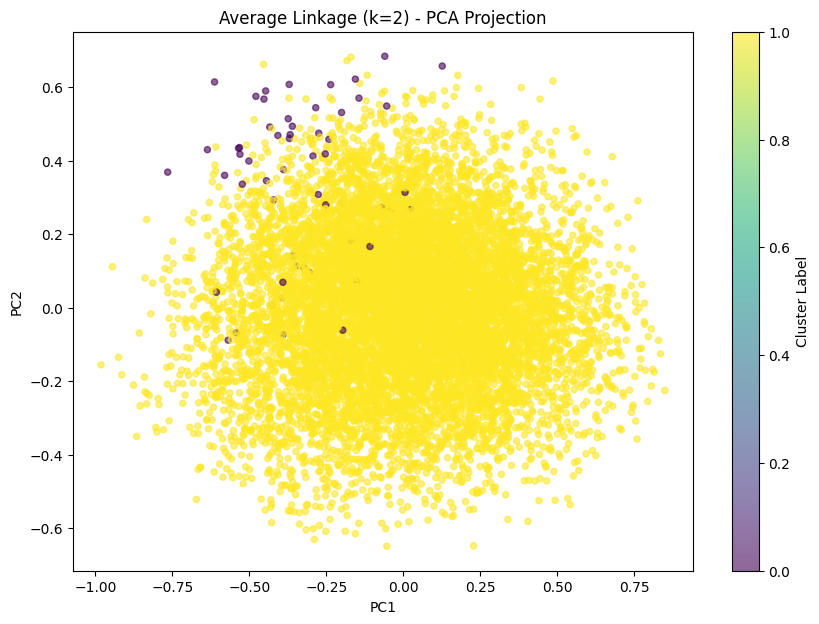


--- CLUSTER PROFILES (Original Scale) ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0        0.103134  38.902810            26.201102  5.062768   35.271186   
1        0.139146  24.658264            28.025775  6.291262   32.944972   

         aggressiveness  
cluster                  
0             -0.322555  
1              0.039650  

--- DEVIATION FROM GLOBAL MEAN ---
         centroid   loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                   
0       -0.035805  14.162729            -1.814193 -1.221438    2.312853   
1        0.000207  -0.081817             0.010481  0.007056   -0.013361   

         aggressiveness  
cluster                  
0             -0.360124  
1              0.002080  


In [ ]:
average_results = analyze_hierarchical_method(X_scaled, X, method='average')